New Updated code


In [1]:
import pandas as pd

# Load the Excel file
df = pd.read_excel('EastWestAirlines.xlsx', sheet_name='data')  # Replace 'data' with actual sheet name
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [2]:
# Drop non-numeric or identifier columns
df.drop(columns=['ID#'], inplace=True, errors='ignore')

# Check for missing values
df.isnull().sum()

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_df = scaler.fit_transform(df)

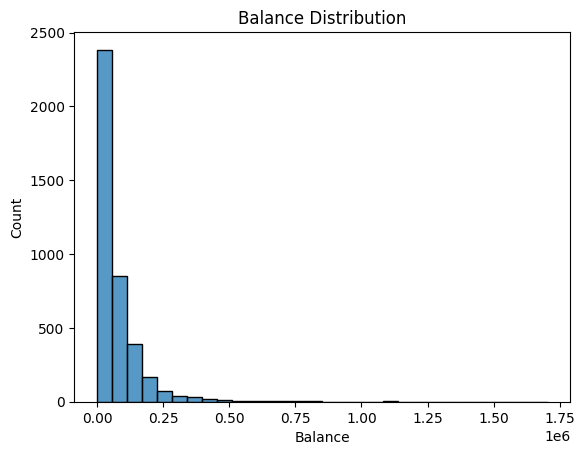

<Axes: >

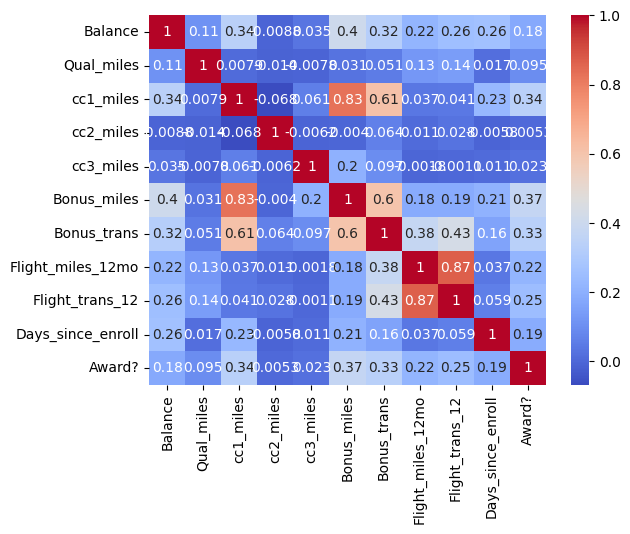

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# Distribution of a few features
sns.histplot(df['Balance'], bins=30)
plt.title('Balance Distribution')
plt.show()

# Correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

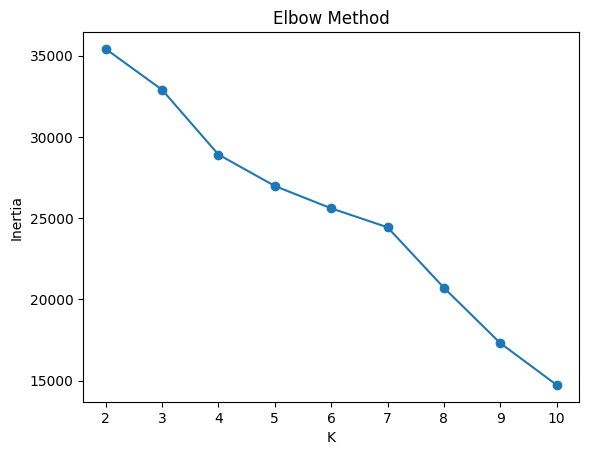

K-Means Silhouette Score: 0.2005393837499611


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Elbow method
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.show()

# Choose optimal K and fit model
kmeans = KMeans(n_clusters=5, random_state=42)
labels_kmeans = kmeans.fit_predict(scaled_df)
print("K-Means Silhouette Score:", silhouette_score(scaled_df, labels_kmeans))

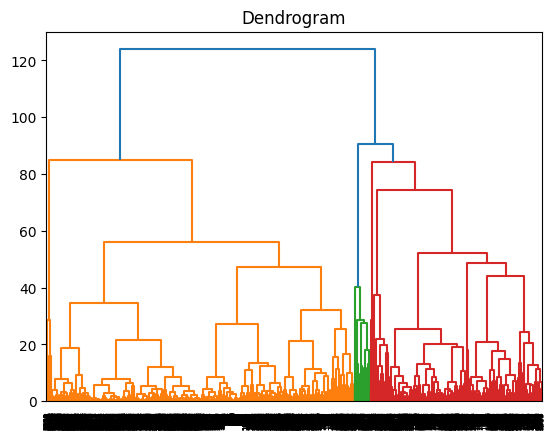

Hierarchical Silhouette Score: 0.3098805307874414


In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

linked = linkage(scaled_df, method='ward')
dendrogram(linked)
plt.title('Dendrogram')
plt.show()

hc = AgglomerativeClustering(n_clusters=5)
labels_hc = hc.fit_predict(scaled_df)
print("Hierarchical Silhouette Score:", silhouette_score(scaled_df, labels_hc))

In [6]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=2, min_samples=5)
labels_dbscan = dbscan.fit_predict(scaled_df)

# Filter noise
if len(set(labels_dbscan)) > 1:
    print("DBSCAN Silhouette Score:", silhouette_score(scaled_df, labels_dbscan))
else:
    print("DBSCAN did not form multiple clusters.")

DBSCAN Silhouette Score: 0.25376617762145437


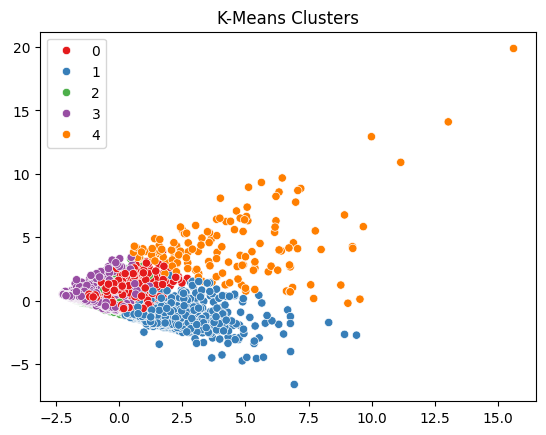

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(scaled_df)

sns.scatterplot(x=reduced_data[:, 0], y=reduced_data[:, 1], hue=labels_kmeans, palette='Set1')
plt.title('K-Means Clusters')
plt.show()